# 07 · Score de saúde por produto

**Projeto:** Cronos · Challenge FIAP 2026 com Locaweb
**Autores:** Ana Beatriz Costa de Oliveira · Hygor Abrantes · Igor Vignola
**Criado em:** 05/08/2026 · **Atualizado em:** 17/08/2026

Nota de 0 a 100 por produto sintetizando a condição operacional, com ranking, tendência e
decomposição da nota nos componentes. É o segundo diferencial declarado nas Sprints 1 e 2.

A primeira questão a resolver não é como calcular a nota, e sim se ela acrescenta informação ao
modelo de risco do notebook 04. Uma nota que reproduzisse a média do risco por produto seria o modelo
anterior reagrupado. A seção 3 responde isso antes de qualquer construção.

**Janela:** incidentes elegíveis ao KPI abertos entre 01/01/2025 e 30/09/2025, acompanhando o corte
da aplicação.

**Entrada:** `data/interim/incidentes_kpi.parquet`, gerado pelo notebook 02.
**Saída:** figuras em `notebooks/figures/07_saude_produto/` e `data/interim/07_saude_produto.parquet`.
**Bibliotecas:** pandas, numpy, matplotlib (Python 3.11+).

In [1]:
# Stdlib
import re
import warnings
from itertools import combinations
from pathlib import Path

# Third-party
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Configurações
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Raiz do repositório (permite executar o notebook de qualquer diretório)
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data' / 'interim').exists())

## 1. Setup

Estilo dos gráficos, caminhos, volume mínimo para entrar no ranking e funções de formatação.

In [2]:
COR = {'preto': '#000000', 'cinza_esc': '#444444', 'cinza': '#888888',
       'accent': '#2563EB', 'danger': '#DC2626', 'ambar': '#D97706', 'verde': '#15A05B'}
mpl.rcParams.update({
    'figure.dpi': 110, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#444444', 'axes.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 12.5, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.grid': True, 'axes.axisbelow': True, 'grid.color': '#E5E5E5', 'grid.linewidth': 0.5,
    'xtick.color': '#888888', 'ytick.color': '#888888',
    'font.family': 'sans-serif', 'font.sans-serif': ['Segoe UI', 'DejaVu Sans'], 'font.size': 10,
    'legend.frameon': False,
})
plt.rcParams['axes.grid.axis'] = 'y'

PARQUET = RAIZ / 'data' / 'interim' / 'incidentes_kpi.parquet'
assert PARQUET.exists(), 'parquet não encontrado. Execute o 02_base_kpi.ipynb antes.'
FIG_DIR = RAIZ / 'notebooks' / 'figures' / '07_saude_produto'
FIG_DIR.mkdir(parents=True, exist_ok=True)

MINIMO_INCIDENTES = 200      # volume mínimo para o produto entrar no ranking

def fmt(x, casas=2):
    return f'{x:.{casas}f}'.replace('.', ',')

def fmt_int(x):
    return f'{int(x):,}'.replace(',', '.')

def salvar_fig(fig, nome):
    fig.savefig(FIG_DIR / f'{nome}.png', dpi=150, bbox_inches='tight')

## 2. Carga dos dados

Além da base, são derivadas três marcações usadas como componentes: se o problema do incidente é
inédito, se a causa foi identificada no fechamento, e o tempo de resolução em horas. A marcação de
problema inédito reutiliza a normalização de texto do notebook 05.

O recorte vai até 30/09/2025, acompanhando o relógio da aplicação, e a contagem de frequência do
problema é feita dentro dessa janela.

In [3]:
# O relógio da aplicação está parado em 01/10/2025 às 15h e ela lê a saída deste notebook.
# A nota rodava sobre 2025 inteiro, o que punha outubro a dezembro dentro dela. Efeito medido:
# dois produtos só cruzavam o piso de 200 incidentes graças ao volume posterior ao corte, notas
# mudavam até 19 pontos, e o pior produto trocava de nome.
CORTE = pd.Timestamp('2025-10-01')

df_kpi = pd.read_parquet(PARQUET)
df_kpi['violou'] = (df_kpi['KPI Violado?'] == 'SIM').astype(int)

def normaliza(texto):
    """Mesma normalizacao do 05: substitui identificador de ativo e numeros por marcadores."""
    s = re.sub(r'IC\d{4,}', '<ativo>', str(texto))
    s = re.sub(r'\d+', '<n>', s)
    return re.sub(r'\s+', ' ', s).strip().lower()

df_kpi['problema'] = df_kpi['Descrição resumida'].map(normaliza)
df_kpi['sem_causa'] = df_kpi['Código de fechamento'].isin(['Outro', 'Falha não reproduzida']).astype(int)
df_kpi['horas'] = df_kpi['Duração'] / 3600          # o campo vem em segundos
df_kpi['pri'] = 'P' + df_kpi['Prioridade'].astype(str).str[0]

df_ano = df_kpi[(df_kpi['ano'] == 2025) & (df_kpi['dia'] < CORTE)].copy()

# `inedito` é contado dentro da janela. Sobre a base inteira, um problema aberto em março e
# repetido em novembro seria marcado como não inédito usando novembro para decidir, informação
# que a tela não tem em 01/10.
FREQ = df_ano['problema'].value_counts()
df_ano['vezes'] = df_ano['problema'].map(FREQ)
df_ano['inedito'] = (df_ano['vezes'] == 1).astype(int)

TAXA_BASE = df_ano['violou'].mean()

print(f'Janela da nota: 01/01/2025 a {(CORTE - pd.Timedelta(days=1)).date()}')
print(f'{fmt_int(len(df_ano))} incidentes, {int(df_ano["violou"].sum())} violacoes de OLA')
print(f'taxa de violacao na janela: {fmt(TAXA_BASE * 100)}%')
print(f'produtos distintos: {df_ano["Produto"].astype(str).nunique()}')
print()
print('descartado pelo corte: '
      f'{fmt_int(len(df_kpi[(df_kpi["ano"] == 2025) & (df_kpi["dia"] >= CORTE)]))} incidentes '
      'abertos entre outubro e dezembro')

Janela da nota: 01/01/2025 a 2025-09-30
19.973 incidentes, 188 violacoes de OLA
taxa de violacao na janela: 0,94%
produtos distintos: 46

descartado pelo corte: 5.183 incidentes abertos entre outubro e dezembro


## 3. O score se sobrepõe ao modelo de risco?

O notebook 04 atribui probabilidade de violação a cada incidente, e a média dessas probabilidades por
produto já seria uma nota de produto. Se os demais candidatos a componente contivessem a mesma
informação, este notebook seria redundante.

A verificação compara a taxa de violação observada por produto, que é a grandeza que o modelo de
risco estima, com os outros candidatos. Correlação alta significa que o candidato não acrescenta.

In [4]:
def agrega_produtos(dados):
    g = dados.groupby(dados['Produto'].astype(str)).agg(
        incidentes=('violou', 'size'),
        violacoes=('violou', 'sum'),
        taxa_violacao=('violou', 'mean'),
        prop_inedito=('inedito', 'mean'),
        prop_sem_causa=('sem_causa', 'mean'),
        duracao_mediana_h=('horas', 'median'),
        ativos=('Item de configuração', 'nunique'))
    g['incidentes_por_ativo'] = g['incidentes'] / g['ativos']
    return g[g['incidentes'] >= MINIMO_INCIDENTES]

prod = agrega_produtos(df_ano)

# Tendência: a taxa do trimestre mais recente dentro da janela contra o que veio antes. Antes do
# corte era segundo semestre contra primeiro, e o segundo semestre incluía outubro a dezembro.
tx1 = df_ano[df_ano['mes'] <= 6].groupby(df_ano['Produto'].astype(str))['violou'].mean()
tx2 = df_ano[df_ano['mes'].between(7, 9)].groupby(df_ano['Produto'].astype(str))['violou'].mean()
prod['tendencia'] = (tx2 - tx1).reindex(prod.index)

# P2 e P3 lado a lado. A nota mistura as duas prioridades num número só, e a mistura chega a
# inverter a leitura. Contagem absoluta sempre, taxa só quando a base do produto sustenta.
for pri in ('P2', 'P3'):
    s = df_ano[df_ano['pri'] == pri].groupby(df_ano['Produto'].astype(str))['violou'].agg(['size', 'sum'])
    inc = s['size'].reindex(prod.index).fillna(0).astype(int)
    vio = s['sum'].reindex(prod.index).fillna(0).astype(int)
    prod[f'incidentes_{pri.lower()}'] = inc
    prod[f'violacoes_{pri.lower()}'] = vio
    prod[f'taxa_{pri.lower()}'] = (vio / inc.where(inc >= 100)).round(4)

COMPONENTES = ['taxa_violacao', 'prop_inedito', 'prop_sem_causa',
               'duracao_mediana_h', 'incidentes_por_ativo', 'tendencia']
print(f'{len(prod)} produtos com pelo menos {MINIMO_INCIDENTES} incidentes na janela')
print(f'eles cobrem {prod["incidentes"].sum()/len(df_ano)*100:.0f}% do volume e '
      f'{int(prod["violacoes"].sum())} das {int(df_ano["violou"].sum())} violações')
print()
print('produtos com base de P2 suficiente para taxa própria (100+ incidentes): '
      f'{int(prod["taxa_p2"].notna().sum())} de {len(prod)}')
print()
print('correlação entre a taxa de violação e os demais candidatos:')
correl = prod[COMPONENTES].corr()['taxa_violacao'].drop('taxa_violacao').round(2)
print(correl.to_string())

15 produtos com pelo menos 200 incidentes na janela
eles cobrem 94% do volume e 172 das 188 violações

produtos com base de P2 suficiente para taxa própria (100+ incidentes): 7 de 15

correlação entre a taxa de violação e os demais candidatos:
prop_inedito           -0.09
prop_sem_causa          0.60
duracao_mediana_h      -0.40
incidentes_por_ativo   -0.25
tendencia               0.11


**A proporção de casos inéditos é praticamente independente da taxa de violação: correlação de
−0,09.** Entre os demais candidatos, a correlação com a taxa vai de 0,60, na proporção fechada sem
causa identificada, a −0,40, na duração mediana.

Um produto pode ter taxa de violação baixa e, ao mesmo tempo, concentração alta de problemas
inéditos. Como o notebook 05 mediu que o problema inédito viola o OLA 4,7 vezes mais que o de rotina,
essa combinação corresponde a risco ainda não materializado, e é invisível ao modelo de risco: ele
avalia incidentes isolados, e cada incidente desse produto tem probabilidade individual baixa.

Há uma segunda razão para o score não ser redundante. O modelo de risco só pode usar informação
disponível na abertura, o que exclui código de fechamento e duração. O score não tem essa restrição,
porque descreve o passado em vez de prever. **Os dois artefatos são complementares justamente por
causa da restrição de vazamento que separa suas fontes de informação.**

## 4. Construção

### 4.1 Os componentes

Seis candidatos, todos com direção definida: valor mais alto significa condição pior.

| Componente | O que mede | Fonte |
|---|---|---|
| `taxa_violacao` | proporção de incidentes que violaram o OLA | campo oficial |
| `prop_inedito` | proporção de problemas que aparecem uma única vez | notebook 05 |
| `prop_sem_causa` | proporção fechada como "Outro" ou "Falha não reproduzida" | notebook 05 |
| `duracao_mediana_h` | tempo mediano de resolução | campo `Duração` |
| `incidentes_por_ativo` | quantos incidentes por item de configuração | derivado |
| `tendencia` | variação da taxa entre o terceiro trimestre e o primeiro semestre | derivado |

### 4.2 Teste de redundância entre componentes

Antes de compor a nota é necessário verificar se algum par mede a mesma coisa. Componentes
redundantes dariam peso dobrado ao mesmo fenômeno.

In [5]:
matriz = prod[COMPONENTES].corr().round(2)
print(matriz.to_string())
print()
LIMITE_REDUNDANCIA = 0.80
pares = [(a, b, matriz.loc[a, b]) for i, a in enumerate(COMPONENTES)
         for b in COMPONENTES[i+1:] if abs(matriz.loc[a, b]) >= LIMITE_REDUNDANCIA]
if pares:
    print(f'pares com correlação de módulo acima de {LIMITE_REDUNDANCIA}:')
    for a, b, v in pares:
        print(f'  {a} e {b}: {v}')
else:
    print(f'nenhum par acima de {LIMITE_REDUNDANCIA}')

                      taxa_violacao  prop_inedito  prop_sem_causa  duracao_mediana_h  incidentes_por_ativo  tendencia
taxa_violacao                  1.00         -0.09            0.60              -0.40                 -0.25       0.11
prop_inedito                  -0.09          1.00            0.03               0.29                  0.17       0.21
prop_sem_causa                 0.60          0.03            1.00              -0.40                 -0.57       0.55
duracao_mediana_h             -0.40          0.29           -0.40               1.00                  0.85       0.02
incidentes_por_ativo          -0.25          0.17           -0.57               0.85                  1.00      -0.28
tendencia                      0.11          0.21            0.55               0.02                 -0.28       1.00

pares com correlação de módulo acima de 0.8:
  duracao_mediana_h e incidentes_por_ativo: 0.85


`duracao_mediana_h` e `incidentes_por_ativo` apresentam correlação de 0,85, acima do limite adotado
de 0,80. Manter os dois atribuiria peso duplo ao mesmo fenômeno.

`duracao_mediana_h` fica e `incidentes_por_ativo` sai. O critério é interpretabilidade: tempo de
resolução tem leitura operacional direta, enquanto incidentes por ativo depende do inventário
cadastrado, que varia por produto por razões alheias à condição operacional.

Entre os cinco componentes restantes, a correlação de maior módulo é 0,60, entre taxa de violação e
proporção fechada sem causa identificada.

### 4.3 Construção da nota

Cada componente é convertido em posição relativa dentro do conjunto de produtos avaliados, e a nota é
a média dessas posições, invertida para que 100 corresponda à melhor condição.

**Duas escolhas explícitas.**

A primeira é usar posição relativa em vez do valor absoluto. A consequência é que a nota compara
produtos entre si e não contra um padrão externo: o produto de melhor nota é o melhor do conjunto,
não um produto sem problemas. A alternativa exigiria um valor de referência por componente, que não
existe no material oficial.

A segunda é peso igual para os cinco componentes. Não há base no dado para afirmar que um deles
importe mais para a condição do produto, e atribuir pesos diferentes sem esse lastro seria
arbitrário. A 4.6 mede o quanto o ranking depende dessa escolha.

In [6]:
USADOS = ['taxa_violacao', 'prop_inedito', 'prop_sem_causa', 'duracao_mediana_h', 'tendencia']

def calcula_nota(tabela, componentes, pesos=None):
    """Nota de 0 a 100: média das posições relativas invertidas. 100 é a melhor condição."""
    if pesos is None:
        pesos = {c: 1.0 for c in componentes}
    total = sum(pesos[c] for c in componentes)
    # posicao relativa: 0 para o melhor valor do conjunto, 1 para o pior
    posicoes = pd.DataFrame({c: tabela[c].rank(pct=True) for c in componentes}, index=tabela.index)
    ruim = sum(posicoes[c] * pesos[c] for c in componentes) / total
    return (100 * (1 - ruim)).round(1), posicoes

prod['nota'], POSICOES = calcula_nota(prod, USADOS)
prod['posicao'] = prod['nota'].rank(ascending=False, method='min').astype(int)

ranking = prod.sort_values('nota').copy()
vista = ranking[['posicao', 'nota', 'incidentes', 'violacoes']].copy()
vista['taxa %'] = (ranking['taxa_violacao'] * 100).round(2)
vista['inéditos %'] = (ranking['prop_inedito'] * 100).round(1)
vista['sem causa %'] = (ranking['prop_sem_causa'] * 100).round(1)
vista['duração h'] = ranking['duracao_mediana_h'].round(2)
vista['tendência pp'] = (ranking['tendencia'] * 100).round(2)
print('ranking do pior para o melhor:')
print(vista.to_string())

ranking do pior para o melhor:
         posicao  nota  incidentes  violacoes  taxa %  inéditos %  sem causa %  duração h  tendência pp
Produto                                                                                                
lvps          15  21.3         310          9    2.90        42.3         30.6       1.18          2.98
lrdo          14  25.3         377          5    1.33        67.9         16.4       1.29          0.41
lcsp          13  26.7         223          2    0.90        52.9         23.8       1.31          1.77
lssl          12  30.7         356          5    1.40        62.9         13.8       3.68         -0.90
lrel          11  32.0         382          5    1.31        44.8         14.1       1.46          0.49
lsin          10  41.3        2450         45    1.84        30.6         21.3       1.46         -1.75
lsaa           9  42.7         420          4    0.95        26.0         23.6       1.52         -0.09
lcsi           8  48.0         97

### 4.4 A decomposição da nota

Uma nota sem decomposição não é acionável. Para cada produto, o componente de pior posição relativa
indica onde a condição se deteriora.

In [7]:
def explica_nota(produto):
    p = POSICOES.loc[produto].sort_values(ascending=False)
    nota = prod.loc[produto, 'nota']
    linhas = [f'{produto} · nota {fmt(nota, 1)} · posição {int(prod.loc[produto, "posicao"])} '
              f'de {len(prod)}']
    for comp, pos in p.items():
        valor = prod.loc[produto, comp]
        bruto = (f'{fmt(valor*100, 1)}%' if comp in ('taxa_violacao', 'prop_inedito', 'prop_sem_causa')
                 else (f'{fmt(valor*100, 2)} pp' if comp == 'tendencia' else f'{fmt(valor, 2)} h'))
        marca = 'pior' if pos >= 0.8 else ('melhor' if pos <= 0.2 else '')
        linhas.append(f'   {comp:22s} {bruto:>10s}   posição relativa {fmt(pos, 2)}  {marca}')
    return '\n'.join(linhas)

for produto in ranking.index[:3]:
    print(explica_nota(produto))
    print()

lvps · nota 21,3 · posição 15 de 15
   taxa_violacao                2,9%   posição relativa 1,00  pior
   prop_sem_causa              30,6%   posição relativa 1,00  pior
   tendencia                 2,98 pp   posição relativa 1,00  pior
   prop_inedito                42,3%   posição relativa 0,53  
   duracao_mediana_h          1,18 h   posição relativa 0,40  

lrdo · nota 25,3 · posição 14 de 15
   prop_inedito                67,9%   posição relativa 1,00  pior
   taxa_violacao                1,3%   posição relativa 0,73  
   prop_sem_causa              16,4%   posição relativa 0,73  
   tendencia                 0,41 pp   posição relativa 0,73  
   duracao_mediana_h          1,29 h   posição relativa 0,53  

lcsp · nota 26,7 · posição 13 de 15
   prop_sem_causa              23,8%   posição relativa 0,93  pior
   tendencia                 1,77 pp   posição relativa 0,93  pior
   prop_inedito                52,9%   posição relativa 0,73  
   duracao_mediana_h          1,31 h   posição 

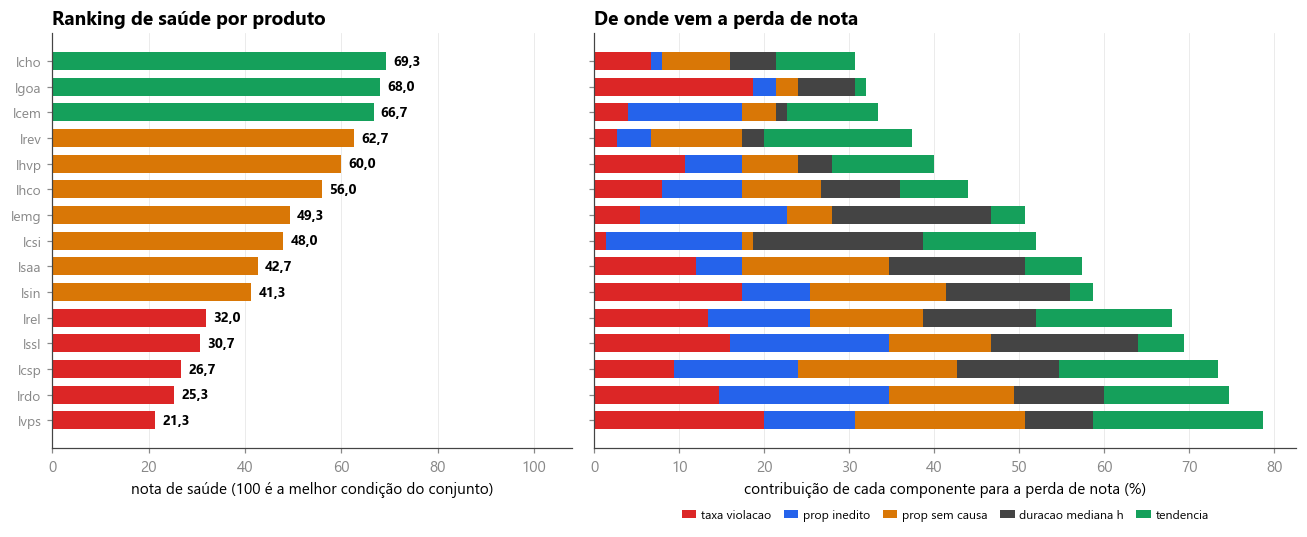

In [8]:
# figura 01: o ranking com a nota decomposta
r = ranking.copy()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.0, 5.0), gridspec_kw={'width_ratios': [1, 1.35]})

cores = [COR['danger'] if n < 40 else (COR['ambar'] if n < 65 else COR['verde']) for n in r['nota']]
ax1.barh(range(len(r)), r['nota'], color=cores, height=0.7)
for i, n in enumerate(r['nota']):
    ax1.text(n + 1.5, i, fmt(n, 1), va='center', fontsize=9, fontweight='bold')
ax1.set_yticks(range(len(r))); ax1.set_yticklabels(r.index, fontsize=9)
ax1.set_xlim(0, 108); ax1.set_xlabel('nota de saúde (100 é a melhor condição do conjunto)')
ax1.set_title('Ranking de saúde por produto', loc='left')
ax1.grid(axis='y', visible=False); ax1.grid(axis='x', visible=True)

paleta = {'taxa_violacao': COR['danger'], 'prop_inedito': COR['accent'],
          'prop_sem_causa': COR['ambar'], 'duracao_mediana_h': COR['cinza_esc'],
          'tendencia': COR['verde']}
pos_r = POSICOES.loc[r.index]
esquerda = np.zeros(len(r))
for comp in USADOS:
    v = pos_r[comp].values / len(USADOS) * 100
    ax2.barh(range(len(r)), v, left=esquerda, color=paleta[comp], height=0.7,
             label=comp.replace('_', ' '))
    esquerda += v
ax2.set_yticks(range(len(r))); ax2.set_yticklabels([], fontsize=9)
ax2.set_xlabel('contribuição de cada componente para a perda de nota (%)')
ax2.set_title('De onde vem a perda de nota', loc='left')
ax2.grid(axis='y', visible=False); ax2.grid(axis='x', visible=True)
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=5,
           fontsize=8, columnspacing=1.0, handletextpad=0.4, handlelength=1.2)
plt.tight_layout(); salvar_fig(fig, '01_ranking_saude'); plt.show()

In [9]:
# o produto lcsi apresenta duracao mediana muito acima das demais; vale isolar a causa
extremo = prod['duracao_mediana_h'].idxmax()
sub = df_ano[df_ano['Produto'].astype(str) == extremo]
print(f'{extremo}: duração mediana de {fmt(prod.loc[extremo, "duracao_mediana_h"], 1)} h '
      f'({fmt(prod.loc[extremo, "duracao_mediana_h"]/24, 1)} dias)')
print(f'   taxa de violação: {fmt(prod.loc[extremo, "taxa_violacao"]*100, 2)}% '
      f'(a menor do conjunto)')
print()
print('   composição por status:')
print('   ' + sub['Status'].astype(str).value_counts(normalize=True).head(3)
      .mul(100).round(1).to_string().replace(chr(10), chr(10) + '   '))
print()
comparacao = df_ano.groupby(df_ano['Status'].astype(str)).agg(
    incidentes=('violou', 'size'), taxa=('violou', 'mean'), dur_h=('horas', 'median'))
comparacao = comparacao[comparacao['incidentes'] >= 200]
comparacao['taxa %'] = (comparacao['taxa'] * 100).round(2)
comparacao['duração mediana h'] = comparacao['dur_h'].round(1)
print('   por status, na base inteira de 2025:')
print('   ' + comparacao[['incidentes', 'taxa %', 'duração mediana h']].to_string()
      .replace(chr(10), chr(10) + '   '))

lcsi: duração mediana de 451,3 h (18,8 dias)
   taxa de violação: 0,10% (a menor do conjunto)

   composição por status:
   Status
   Encerrado Automaticamente    86.2
   Encerrado                    13.8

   por status, na base inteira de 2025:
                              incidentes  taxa %  duração mediana h
   Status                                                          
   Encerrado                        8259    0.99                0.8
   Encerrado Automaticamente       11714    0.90                1.7


O produto `lcsi` apresenta duração mediana de 451,3 horas, cerca de 19 dias, ao lado da menor taxa de
violação do conjunto, 0,10%. Nele o status `Encerrado Automaticamente` responde por 86,2% dos
incidentes.

**A explicação pelo status é parcial.** Na base inteira esse status tem duração mediana de 1,7 h
contra 0,8 h do `Encerrado`, ou seja, é mais longo, mas por um fator de dois, e não pelas duas ordens
de grandeza que separam `lcsi` do conjunto. O que se pode afirmar é que a combinação de duração
altíssima com taxa de violação quase nula reproduz a anomalia documentada na 4.2.1 do notebook 04, em
que incidentes longos encerrados automaticamente não entram na apuração oficial do OLA. A causa
específica de `lcsi` não está determinada com os campos disponíveis.

Consequência para a nota: o componente de duração penaliza `lcsi` por um tempo que reflete
encerramento por inatividade, e não atendimento lento. A nota o coloca em 8º de 15, então o efeito não
domina o resultado, mas a leitura desse componente nesse produto não deve ser feita como tempo de
trabalho.

A alternativa seria excluir os incidentes de encerramento automático do cálculo de duração. Não foi
adotada porque exigiria decidir se esses incidentes representam ou não trabalho da operação, e o
dataset não traz elemento para essa distinção.

### 4.5 Risco latente

O caso que justifica a existência do score: produtos com concentração alta de problemas inéditos e
taxa de violação ainda baixa. A combinação indica exposição que não se materializou no período
medido. O corte em cada eixo é a mediana do conjunto.

In [10]:
mediana_ined = prod['prop_inedito'].median()
mediana_taxa = prod['taxa_violacao'].median()

def quadrante(linha):
    alto_ined = linha['prop_inedito'] > mediana_ined
    alta_taxa = linha['taxa_violacao'] > mediana_taxa
    if alto_ined and alta_taxa:
        return 'problema já materializado'
    if alto_ined and not alta_taxa:
        return 'risco latente'
    if not alto_ined and alta_taxa:
        return 'problema conhecido e recorrente'
    return 'estável'

prod['quadrante'] = prod.apply(quadrante, axis=1)
print(f'mediana de casos inéditos: {fmt(mediana_ined*100, 1)}% | '
      f'mediana da taxa de violação: {fmt(mediana_taxa*100, 2)}%')
print()
resumo = prod.groupby('quadrante').agg(produtos=('nota', 'size'), nota_media=('nota', 'mean')).round(1)
print(resumo.to_string())
print()
for q in ['risco latente', 'problema já materializado']:
    s = prod[prod['quadrante'] == q].sort_values('prop_inedito', ascending=False)
    if len(s):
        print(f'{q}:')
        for i in s.index:
            print(f'   {i}: {fmt(s.loc[i, "prop_inedito"]*100, 1)}% inéditos, '
                  f'taxa de {fmt(s.loc[i, "taxa_violacao"]*100, 2)}%, nota {fmt(s.loc[i, "nota"], 1)}')
        print()

mediana de casos inéditos: 42,3% | mediana da taxa de violação: 0,94%

                                 produtos  nota_media
quadrante                                            
estável                                 4        62.0
problema conhecido e recorrente         4        43.3
problema já materializado               3        29.3
risco latente                           4        47.7

risco latente:
   lemg: 58,8% inéditos, taxa de 0,62%, nota 49,3
   lcsi: 57,9% inéditos, taxa de 0,10%, nota 48,0
   lcsp: 52,9% inéditos, taxa de 0,90%, nota 26,7
   lcem: 44,8% inéditos, taxa de 0,57%, nota 66,7

problema já materializado:
   lrdo: 67,9% inéditos, taxa de 1,33%, nota 25,3
   lssl: 62,9% inéditos, taxa de 1,40%, nota 30,7
   lrel: 44,8% inéditos, taxa de 1,31%, nota 32,0



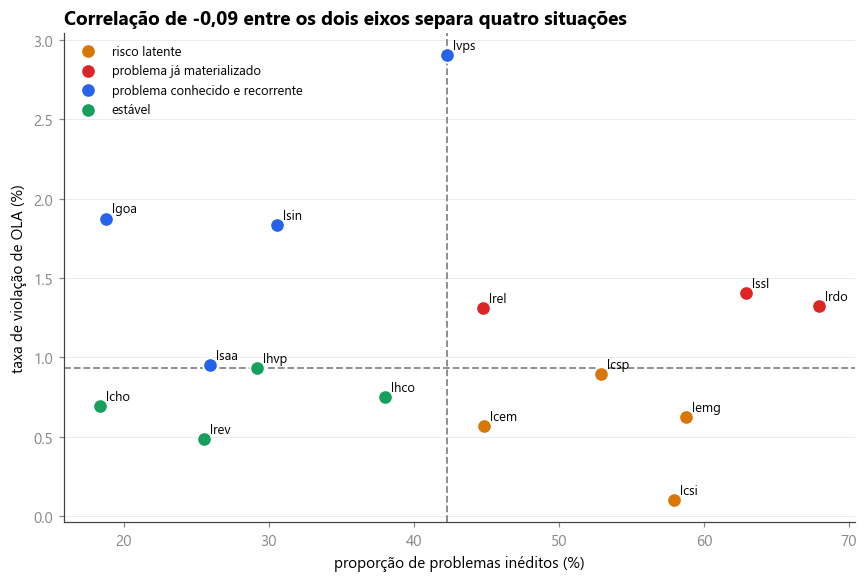

In [11]:
# figura 02: os quadrantes
fig, ax = plt.subplots(figsize=(8.0, 5.4))
mapa = {'risco latente': COR['ambar'], 'problema já materializado': COR['danger'],
        'problema conhecido e recorrente': COR['accent'], 'estável': COR['verde']}
for q, cor in mapa.items():
    s = prod[prod['quadrante'] == q]
    if not len(s):
        continue
    ax.scatter(s['prop_inedito'] * 100, s['taxa_violacao'] * 100, s=90, color=cor,
               label=q, zorder=4, edgecolors='white', linewidths=1.2)
    for i in s.index:
        ax.annotate(i, xy=(s.loc[i, 'prop_inedito'] * 100, s.loc[i, 'taxa_violacao'] * 100),
                    xytext=(4, 4), textcoords='offset points', fontsize=8.5)
ax.axvline(mediana_ined * 100, color=COR['cinza'], lw=1.2, ls='--')
ax.axhline(mediana_taxa * 100, color=COR['cinza'], lw=1.2, ls='--')
ax.set_xlabel('proporção de problemas inéditos (%)')
ax.set_ylabel('taxa de violação de OLA (%)')
r_eixos = prod['taxa_violacao'].corr(prod['prop_inedito'])
ax.set_title(f'Correlação de {fmt(r_eixos, 2)} entre os dois eixos separa quatro situações',
             loc='left')
ax.legend(loc='upper left', fontsize=8.5)
plt.tight_layout(); salvar_fig(fig, '02_quadrantes'); plt.show()

**Como ler o gráfico.** O eixo horizontal mede quanto do que acontece no produto é problema novo. O
eixo vertical mede quanto de fato violou o OLA. As linhas tracejadas são as medianas do conjunto,
42,3% e 0,94%, e dividem os produtos em quatro situações:

| Situação | Problema novo | Violação | Leitura |
|---|---|---|---|
| **problema já materializado** | acima da mediana | acima | recebe casos novos e já está violando |
| **risco latente** | acima da mediana | abaixo | recebe casos novos e ainda não violou |
| **problema conhecido e recorrente** | abaixo | acima | viola, mas sempre pelo mesmo motivo |
| **estável** | abaixo | abaixo | sem sinal de deterioração |

A divisão só produz quatro grupos porque os dois eixos são praticamente independentes, com correlação
de −0,09. Se fossem correlacionados, os produtos se alinhariam na diagonal e haveria uma dimensão de
variação, não quatro situações.

O quadrante de **risco latente** é o que justifica a existência deste notebook, e reúne quatro
produtos: `lemg`, `lcsi`, `lcsp` e `lcem`. Como o notebook 05 mediu que o problema inédito viola o OLA
4,7 vezes mais que o de rotina, esses produtos acumulam a característica associada à violação sem que
ela tenha se materializado no período observado. Nenhum deles seria sinalizado pelo modelo de risco,
porque a avaliação é por incidente e cada caso recebe probabilidade individual baixa: o padrão existe
apenas no agregado do produto.

O quadrante de **problema conhecido e recorrente** exige leitura oposta: o produto viola, mas por
motivo repetido. É a situação em que padronizar a resposta tende a resolver, ao contrário do risco
latente, em que o problema ainda não é conhecido o suficiente para ser padronizado.

### 4.6 Sensibilidade da nota aos pesos

O peso igual entre componentes é escolha sem lastro no dado, então é necessário medir o quanto o
resultado depende dela. O teste recalcula a nota dobrando o peso de um componente por vez e mede a
concordância de ordem com o ranking original.

In [12]:
def concordancia(a, b):
    """Proporção de pares de produtos que mantêm a ordem relativa entre dois rankings."""
    itens = list(a.index)
    iguais = sum(1 for x, y in combinations(itens, 2)
                 if (a[x] - a[y]) * (b[x] - b[y]) > 0)
    return iguais / len(list(combinations(itens, 2)))

base_nota = prod['nota']
linhas = []
for comp in USADOS:
    pesos = {c: (2.0 if c == comp else 1.0) for c in USADOS}
    nota_alt, _ = calcula_nota(prod, USADOS, pesos)
    linhas.append({'peso dobrado em': comp,
                   'concordância do ranking %': round(concordancia(base_nota, nota_alt) * 100, 1),
                   'variação máxima da nota': round((nota_alt - base_nota).abs().max(), 1),
                   'muda o pior colocado': ranking.index[0] != nota_alt.idxmin()})
print(pd.DataFrame(linhas).to_string(index=False))
print()
# so a taxa de violacao, para comparar com o que o modelo de risco entregaria
so_taxa = (100 * (1 - prod['taxa_violacao'].rank(pct=True))).round(1)
print(f'concordância entre a nota composta e um ranking feito só pela taxa de violação: '
      f'{fmt(concordancia(base_nota, so_taxa)*100, 1)}%')

  peso dobrado em  concordância do ranking %  variação máxima da nota  muda o pior colocado
    taxa_violacao                       94.3                     10.2                 False
     prop_inedito                       91.4                      6.0                  True
   prop_sem_causa                       92.4                      7.6                 False
duracao_mediana_h                       93.3                      8.0                  True
        tendencia                       90.5                      8.3                 False

concordância entre a nota composta e um ranking feito só pela taxa de violação: 67,6%


Dobrar o peso de qualquer componente preserva de 90,5% a 94,3% da ordem entre produtos, com variação
máxima de nota entre 6,0 e 10,2 pontos. O ranking não é artefato da escolha de pesos iguais. Em dois
casos o pior colocado troca, o que é esperado num conjunto de 15 produtos com notas próximas na
cauda.

O segundo número é o que sustenta a existência deste notebook: **a concordância entre a nota composta
e um ranking feito apenas com a taxa de violação é de 67,6%**. Um terço dos pares de produtos troca de
ordem, ou seja, a nota carrega informação que o modelo de risco não expressa.

### 4.7 Saída para a aplicação

Tabela por produto com nota, posição, quadrante e os componentes em valor bruto e em posição
relativa, para que a interface exiba a decomposição junto da nota. As colunas por prioridade viajam
junto, porque a nota mistura P2 e P3 num número só e a tela precisa mostrar as duas ao lado dela sem
refazer a conta.

In [13]:
saida = prod.copy()
for comp in USADOS:
    saida[f'pos_{comp}'] = POSICOES[comp].round(3)

# As colunas por prioridade viajam para a aplicação: a nota mistura P2 e P3 num número só, e a
# tela precisa poder mostrar as duas ao lado dela sem refazer a conta.
PRI = ['incidentes_p2', 'violacoes_p2', 'taxa_p2',
       'incidentes_p3', 'violacoes_p3', 'taxa_p3']
colunas = (['posicao', 'nota', 'quadrante', 'incidentes', 'violacoes'] + USADOS
           + [f'pos_{c}' for c in USADOS] + PRI)
saida = saida[colunas].sort_values('posicao')
saida.attrs['janela'] = f'2025-01-01 a {(CORTE - pd.Timedelta(days=1)).date()}'

destino = RAIZ / 'data' / 'interim' / '07_saude_produto.parquet'
saida.to_parquet(destino)
print(f'{destino.name}: {len(saida)} linhas · {saida.shape[1]} colunas')
print(f'janela: 2025-01-01 a {(CORTE - pd.Timedelta(days=1)).date()}')
print()
print(saida.head(5).round(3).to_string())
print()
print('o produto de pior nota e o de melhor, com as duas prioridades:')
extremos = saida.iloc[[0, -1]][['nota', 'incidentes', 'violacoes', 'taxa_violacao',
                                'incidentes_p2', 'taxa_p2', 'incidentes_p3', 'taxa_p3']]
print(extremos.round(4).to_string())

07_saude_produto.parquet: 15 linhas · 21 colunas
janela: 2025-01-01 a 2025-09-30

         posicao  nota                        quadrante  incidentes  violacoes  taxa_violacao  prop_inedito  prop_sem_causa  duracao_mediana_h  tendencia  pos_taxa_violacao  pos_prop_inedito  pos_prop_sem_causa  pos_duracao_mediana_h  pos_tendencia  incidentes_p2  violacoes_p2  taxa_p2  incidentes_p3  violacoes_p3  taxa_p3
Produto                                                                                                                                                                                                                                                                                                                             
lcho           1  69.3                          estável         431          3          0.007         0.183           0.104              0.976      0.000              0.333             0.067               0.400                  0.267          0.467            190     

## 5. Conclusão

**O score não é redundante com o modelo de risco.** A correlação entre taxa de violação e proporção de
problemas inéditos é de −0,09, e a concordância entre a nota composta e um ranking feito apenas pela
taxa de violação é de 67,6%. A nota ordena os produtos de forma substancialmente diferente.

Os dois artefatos são complementares por causa da restrição de vazamento: o modelo de risco só pode
usar informação disponível na abertura, enquanto o score descreve o passado e por isso pode usar
código de fechamento e duração, campos que o modelo é obrigado a excluir.

**Existe um quadrante de risco latente**, com quatro produtos que concentram problemas inéditos acima
da mediana e ainda registram violação abaixo dela. Como o problema inédito viola o OLA 4,7 vezes mais,
essa combinação representa exposição não materializada, invisível a uma avaliação por incidente.

A nota usa posição relativa em vez de valor absoluto, porque não existe valor de referência por
componente no material oficial, e peso igual entre os cinco componentes, por ausência de base no dado
para diferenciá-los. Dobrar o peso de qualquer um preserva de 90,5% a 94,3% da ordem. Dois candidatos
eram redundantes entre si, com correlação de 0,85, e `incidentes_por_ativo` foi descartado.

Seis limitações ficam declaradas. O conjunto tem 15 produtos, os que superam 200 incidentes na janela,
e a nota é relativa a esse conjunto, portanto não é comparável entre execuções com conjuntos
diferentes. A tendência é medida entre o terceiro trimestre e o primeiro semestre de um único ano, o
que a torna sensível a evento isolado. O quadrante de risco latente é hipótese fundamentada e não
previsão validada: verificar exigiria observar se esses produtos passam a violar mais no período
seguinte, e há um ano só de dado. Dois componentes usam campos preenchidos no fechamento, o que é
adequado a diagnóstico e impede usar a nota como previsão. E o componente de duração é distorcido em
`lcsi` por encerramento automático, sem que esses incidentes tenham sido excluídos, porque o dataset
não permite decidir se representam trabalho da operação.